In [1]:
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from src.saws_functions import sarg_grid_from_sat  # noqa: E402

In [2]:
end_images = [
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -63.0, -38.0],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [22.0, 0.0, -38.0, -11.5],
    },
    {
        'image_name': "../SaWSdata/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png",
        'bbox': [23.0, 10.0, -75.0, -60.0],
    },
]
sarg_final_lon, sarg_final_lat, _ = sarg_grid_from_sat(end_images, coarse=True)

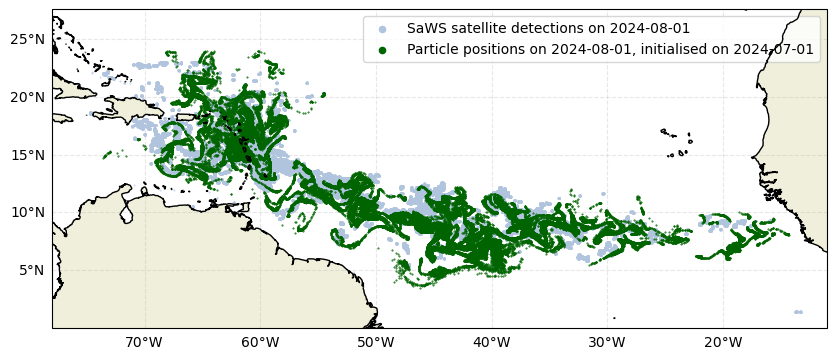

In [3]:
ds = xr.open_zarr("Simulation_Satellite_kN_0.001.zarr").dropna(dim='obs', how='all')

fig = plt.figure(figsize = (10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

satplot = ax.scatter(sarg_final_lon, sarg_final_lat, s = 0.11, c='lightsteelblue', label='SaWS satellite detections on 2024-08-01',zorder=6)
label = f'Particle positions on {ds.time[0, -1].values.astype("datetime64[D]")}, initialised on {ds.time[0, 0].values.astype("datetime64[D]")}'
eplot = ax.scatter(ds.lon[:,-1], ds.lat[:,-1], s = 0.2 ,color='darkgreen', label = label ,zorder=7)

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=8)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_extent([-78, -11, 0, 24])
leg = ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([20])

fig.savefig('Figure2.png', bbox_inches='tight', dpi=300)

plt.show()